<a href="https://colab.research.google.com/github/AdnaneBenatik/DeepLearning-Project/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Étape 1 : Implémentation "From Scratch" de la Convolution et du Pooling

Pour assimiler les mécanismes mathématiques bas niveau qui régissent les réseaux de neurones convolutifs (CNN), cette section propose de programmer les opérations fondamentales sans utiliser les fonctions pré-packagées de PyTorch.

* **Corrélation Croisée 2D (`corr2d_custom`) :** C'est l'opération de base d'une couche convolutive en Deep Learning. Un noyau (filtre) de taille fixe glisse sur l'image. À chaque étape, on effectue un produit terme à terme entre la zone de l'image (le champ récepteur) et le noyau, puis on additionne le tout.
  La formule théorique qui détermine la dimension de la matrice de sortie (sans padding et avec un déplacement ou stride de 1) est :
  $$N_{out} = (N_{in} - F + 1)$$
  Où $N_{in}$ est la taille de l'entrée et $F$ la taille du filtre.

* **Le Pooling Custom (`pool2d_custom`) :** Le pooling sert à réduire la résolution spatiale des images pour compresser l'information et réduire le coût de calcul. Il n'y a aucun paramètre à apprendre ici.
  *Le Max-Pooling* extrait la valeur maximale d'une zone (idéal pour capturer les contrastes forts), tandis que *l'Average-Pooling* calcule la moyenne (idéal pour lisser le signal).

* **Validation numérique :** Pour valider notre algorithme, nous injectons la matrice de test $3 \times 3$ de notre fiche de synthèse. Le premier pixel calculé à la main doit donner :
  $$0 \times 0 + 1 \times 1 + 3 \times 2 + 4 \times 3 = 19$$
  Le script ci-dessous permet de confirmer la parfaite exactitude de nos fonctions.

In [ ]:
import torch
import numpy as np

# 1. IMPLÉMENTATION "FROM SCRATCH" DE LA CORRÉLATION CROISÉE 2D
def corr2d_custom(X, K):
    """
    X : Matrice d'entrée 2D (Tenseur PyTorch)
    K : Noyau / Filtre de convolution 2D
    Retourne le résultat de la corrélation croisée 2D
    """
    h, w = K.shape
    # Formule mathématique de la taille de sortie : (H - h + 1) x (W - w + 1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # Extraction de la fenêtre locale (Champ récepteur)
            region = X[i:i+h, j:j+w]
            # Produit terme à terme (Hadamard) puis somme totale
            Y[i, j] = (region * K).sum()
    return Y


# 2. IMPLÉMENTATION "FROM SCRATCH" DU POOLING (MAX ET AVERAGE)
def pool2d_custom(X, pool_size=(2, 2), mode='max'):
    """
    X : Matrice d'entrée 2D
    pool_size : Taille de la fenêtre de pooling (hauteur, largeur)
    mode : 'max' pour le Max-Pooling, 'avg' pour l'Average-Pooling
    """
    p_h, p_w = pool_size
    # Hypothèse d'un Stride égal à la taille de la fenêtre (comportement par défaut)
    Y = torch.zeros((X.shape[0] // p_h, X.shape[1] // p_w))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # Calcul des indices avec le saut du Stride
            start_h, start_w = i * p_h, j * p_w
            region = X[start_h:start_h+p_h, start_w:start_w+p_w]

            if mode == 'max':
                Y[i, j] = region.max()
            elif mode == 'avg':
                Y[i, j] = region.mean()
    return Y


# ==========================================
# TEST NUMÉRIQUE ET VALIDATION SCIENTIFIQUE
# ==========================================
print("--- 1. TEST DE LA CONVOLUTION / CORRÉLATION CROISÉE ---")
# Matrice d'entrée et Noyau identiques à l'exemple numérique de la fiche
X_mat = torch.tensor([[0.0, 1.0, 2.0],
                      [3.0, 4.0, 5.0],
                      [6.0, 7.0, 8.0]])

K_mat = torch.tensor([[0.0, 1.0],
                      [2.0, 3.0]])

Y_conv_custom = corr2d_custom(X_mat, K_mat)
print("Entrée X :\n", X_mat)
print("Noyau K :\n", K_mat)
print("Résultat attendu théorique : [[19, 25], [37, 43]]")
print("Résultat calculé Custom :\n", Y_conv_custom)

print("\n--- 2. TEST DES COUCHES DE POOLING ---")
# Matrice d'entrée 4x4 pour tester le pooling
X_pool = torch.tensor([[0.0,  1.0,  2.0,  3.0],
                       [4.0,  5.0,  6.0,  7.0],
                       [8.0,  9.0,  10.0, 11.0],
                       [12.0, 13.0, 14.0, 15.0]])

print("Résultat Max-Pooling 2x2 Custom :\n", pool2d_custom(X_pool, (2, 2), mode='max'))
print("Résultat Average-Pooling 2x2 Custom :\n", pool2d_custom(X_pool, (2, 2), mode='avg'))

--- 1. TEST DE LA CONVOLUTION / CORRÉLATION CROISÉE ---
Entrée X :
 tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])
Noyau K :
 tensor([[0., 1.],
        [2., 3.]])
Résultat attendu théorique : [[19, 25], [37, 43]]
Résultat calculé Custom :
 tensor([[19., 25.],
        [37., 43.]])

--- 2. TEST DES COUCHES DE POOLING ---
Résultat Max-Pooling 2x2 Custom :
 tensor([[ 5.,  7.],
        [13., 15.]])
Résultat Average-Pooling 2x2 Custom :
 tensor([[ 2.5000,  4.5000],
        [10.5000, 12.5000]])


### Étape 2 : Préparation de Fashion-MNIST et Extraction de Contours

Cette étape formalise la création de notre pipeline de données réel et simule le comportement d'extraction de caractéristiques d'une première couche de CNN.

* **Le Dataset Fashion-MNIST :** Ce jeu de données de référence comprend 70 000 images d'articles de mode (vêtements, chaussures, sacs) standardisées en niveaux de gris ($28 \times 28 \times 1$). Nous appliquons une séparation stricte : 80% pour l'entraînement (48 000 images) et 20% pour la validation (12 000 images). Un jeu de test de 10 000 images est isolé pour l'évaluation finale.

* **Normalisation :** Les données subissent une transformation via `transforms.Normalize((0.5,), (0.5,))` pour ramener la distribution des pixels autour d'une moyenne de 0 et d'un écart-type de 1, ce qui stabilise la descente de gradient.

* **Extraction de caractéristiques (Filtre de Sobel) :** Nous appliquons un filtre mathématique fixe de Sobel horizontal sur une image brute du dataset. Ce noyau possède la structure suivante :
  $$K = \begin{pmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{pmatrix}$$
  Son but est de calculer le gradient d'intensité horizontal. Le graphique généré met en évidence la suppression des aplats de couleurs au profit des frontières géométriques de l'objet (silhouettes, coutures, formes). C'est exactement le rôle des premiers filtres appris automatiquement par un CNN.

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.26MB/s]


Dataset prêt ! Train : 48000 images | Val : 12000 images | Test : 10000 images



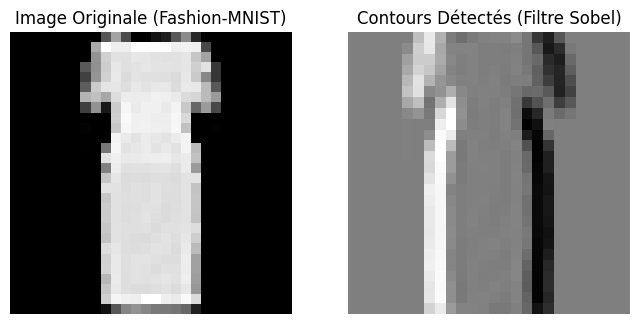

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CHARGEMENT ET PRÉPARATION DU DATASET
# ==========================================
# Transformation : conversion en tenseur et normalisation autour de 0
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Téléchargement automatique via torchvision
dataset_train_complet = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataset_test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Séparation Train (80%) / Validation (20%) pour le tuning des hyperparamètres
taille_train = int(0.8 * len(dataset_train_complet))
taille_val = len(dataset_train_complet) - taille_train
dataset_train, dataset_val = random_split(dataset_train_complet, [taille_train, taille_val], generator=torch.Generator().manual_seed(42))

# Initialisation du flux de données par paquets (batch_size=64)
train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=64, shuffle=False)

print(f"Dataset prêt ! Train : {len(dataset_train)} images | Val : {len(dataset_val)} images | Test : {len(dataset_test)} images\n")


# 2. EXPÉRIENCE DE DÉTECTION DE CONTOURS
# ==========================================
# Extraction d'une image d'exemple
images, labels = next(iter(train_loader))
img_brute = images[0][0] # On prend la première image du premier batch (matrice 28x28)

# Définition d'un filtre de Sobel horizontal (noyau 3x3) pour détecter les contrastes verticaux
noyau_sobel = torch.tensor([[-1.0, 0.0, 1.0],
                            [-2.0, 0.0, 2.0],
                            [-1.0, 0.0, 1.0]])

# Application de notre fonction custom de l'étape 1
img_contours = corr2d_custom(img_brute, noyau_sobel)

# Visualisation du résultat
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_brute, cmap='gray')
plt.title("Image Originale (Fashion-MNIST)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_contours, cmap='gray')
plt.title("Contours Détectés (Filtre Sobel)")
plt.axis('off')
plt.show()

### Étape 3 : Définition de l'Architecture LeNet-5 Modernisée

Cette section formalise la création de notre modèle de Deep Learning en utilisant l'écosystème natif de PyTorch. Nous implémentons une variante optimisée du réseau historique **LeNet-5**.

* **Architecture en entonnoir :** Le réseau est conçu en deux blocs distincts. D'abord, un extracteur de caractéristiques (`self.features`) qui augmente le nombre de canaux (de 1 à 16) tout en compressant la taille géométrique des images. Ensuite, un classifieur dense (`self.classifier`) qui fusionne ces cartes abstraites pour prendre la décision finale.
* **Modernisation des opérateurs :** Contrairement au modèle de 1998, nous remplaçons l'activation *Sigmoid* par l'activation *ReLU* afin d'éliminer le phénomène de disparition du gradient et accélérer la vitesse de calcul. De même, nous préférons le *Max-Pooling* à l' *Average-Pooling* pour capter plus efficacement les contrastes dominants des vêtements.
* **Rigueur mathématique du flux :** La formule des dimensions vue à l'étape 1 est appliquée à chaque étape de convolution et de pooling. Le script intègre un affichage dynamique qui permet de suivre la transformation de notre tenseur, passant d'une image matricielle de $(1, 28, 28)$ à un vecteur sémantique de 400 neurones, garantissant l'absence d'incohérence dimensionnelle avant l'injection dans les couches denses.

In [ ]:
import torch.nn as nn
import torch

class LeNet5Modernise(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5Modernise, self).__init__()

        # 1. BLOC D'EXTRACTION DE CARACTÉRISTIQUES (CONVOLUTIONS + POOLING)
        self.features = nn.Sequential(
            # Première couche : 1 canal d'entrée (gris) -> 6 filtres de sortie.
            # Le padding de 2 permet de conserver la taille spatiale à 28x28 malgré le filtre 5x5.
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2),
            nn.ReLU(),
            # Réduction de la taille par 2 -> Sortie : 6 cartes de taille 14x14
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Deuxième couche : 6 canaux -> 16 filtres de sortie. Pas de padding.
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=0),
            nn.ReLU(),
            # Réduction de la taille par 2 -> Sortie finale features : 16 cartes de taille 5x5
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 2. BLOC DE CLASSIFICATION (COUCHES ENTIÈREMENT CONNECTÉES / DENSES)
        self.classifier = nn.Sequential(
            # Aplatissement des cartes 2D en un seul vecteur linéaire (16 * 5 * 5 = 400 éléments)
            nn.Flatten(),

            # Couche dense 1 : 400 -> 120 neurones
            nn.Linear(in_features=400, out_features=120),
            nn.ReLU(),

            # Couche dense 2 : 120 -> 84 neurones
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),

            # Couche de sortie : 84 -> 10 neurones (un par classe de vêtement)
            nn.Linear(in_features=84, out_features=num_classes)
        )

    def forward(self, x):
        # Passage séquentiel de la donnée à travers les filtres puis le classifieur
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciation du modèle sur l'appareil disponible (CPU ou GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = LeNet5Modernise(num_classes=10).to(device)

# --- TRACKING DYNAMIQUE DES DIMENSIONS ---
print("--- VÉRIFICATION DU FLUX DES DIMENSIONS ---")
x_virtuel = torch.randn(1, 1, 28, 28).to(device) # Simulation d'une image Fashion-MNIST
print(f"Dimension brute en entrée : {x_virtuel.shape}")

with torch.no_grad():
    for i, couche in enumerate(model_cnn.features):
        x_virtuel = couche(x_virtuel)
        print(f"Après la couche features [{i}] ({couche.__class__.__name__:.<12}) -> Dimension : {x_virtuel.shape}")

    # Simulation de la vectorisation avant le classifieur
    x_flat = nn.Flatten()(x_virtuel)
    print(f"Après l'opération de Flatten (Aplatissement)   -> Dimension : {x_flat.shape}")

--- VÉRIFICATION DU FLUX DES DIMENSIONS ---
Dimension brute en entrée : torch.Size([1, 1, 28, 28])
Après la couche features [0] (Conv2d......) -> Dimension : torch.Size([1, 6, 28, 28])
Après la couche features [1] (ReLU........) -> Dimension : torch.Size([1, 6, 28, 28])
Après la couche features [2] (MaxPool2d...) -> Dimension : torch.Size([1, 6, 14, 14])
Après la couche features [3] (Conv2d......) -> Dimension : torch.Size([1, 16, 10, 10])
Après la couche features [4] (ReLU........) -> Dimension : torch.Size([1, 16, 10, 10])
Après la couche features [5] (MaxPool2d...) -> Dimension : torch.Size([1, 16, 5, 5])
Après l'opération de Flatten (Aplatissement)   -> Dimension : torch.Size([1, 400])


### Étape 4 : Configuration et Boucle d'Entraînement du CNN

Cette étape déclenche le processus d'apprentissage du réseau LeNet-5 sur nos images Fashion-MNIST.

* **Fonction de Perte (Loss) :** Le problème étant une classification multi-classe (10 catégories de vêtements exclusives), nous utilisons `nn.CrossEntropyLoss()`. Sur le plan mathématique, cette fonction combine un `LogSoftmax` (pour transformer les sorties brutes en probabilités) et une `NLLLoss` (Negative Log Likelihood) pour pénaliser fortement les prédictions divergentes de la réalité.
* **Optimiseur :** L'algorithme **Adam** est privilégié avec un taux d'apprentissage de 0.001. Sa capacité à adapter dynamiquement le pas de gradient pour chaque paramètre (poids et biais de nos filtres) permet une convergence très rapide, particulièrement adaptée aux architectures convolutives.
* **Boucle (Époques) :** À chaque itération (batch de 64 images), le modèle effectue une passe avant (*forward*), calcule l'erreur, calcule les gradients de chaque filtre convolutif via la rétropropagation (*backward*), puis met à jour ses poids (*step*).

In [ ]:
import torch.optim as optim

# 1. DÉFINITION DU MOTEUR D'APPRENTISSAGE
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

# 2. PARAMÈTRES D'ENTRAÎNEMENT
epochs = 5  # 5 époques suffisent pour démontrer la convergence sur ce dataset
print("======================================================")
print(f"Lancement de l'entraînement du CNN sur {device.type.upper()}...")
print("======================================================")

# 3. BOUCLE D'ENTRAÎNEMENT
historique_loss = []

for epoch in range(epochs):
    model_cnn.train() # Activation du mode apprentissage (active le calcul du gradient)
    running_loss = 0.0

    # On parcourt les images par paquets (batchs de 64)
    for images, labels in train_loader:
        # Transfert des données sur la mémoire de l'appareil (GPU/CPU)
        images, labels = images.to(device), labels.to(device)

        # Remise à zéro des gradients de l'itération précédente
        optimizer.zero_grad()

        # Passe avant : le CNN fait sa prédiction
        outputs = model_cnn(images)

        # Calcul de l'erreur mathématique
        loss = criterion(outputs, labels)

        # Rétropropagation : calcul des dérivées pour ajuster les filtres
        loss.backward()

        # Mise à jour des poids du réseau
        optimizer.step()

        running_loss += loss.item()

    # Affichage des statistiques de fin d'époque
    loss_moyenne = running_loss / len(train_loader)
    historique_loss.append(loss_moyenne)
    print(f"Époque [{epoch+1}/{epochs}] - Loss moyenne d'entraînement : {loss_moyenne:.4f}")

print("======================================================")
print("Entraînement terminé avec succès !")

Lancement de l'entraînement du CNN sur CPU...
Époque [1/5] - Loss moyenne d'entraînement : 0.6279
Époque [2/5] - Loss moyenne d'entraînement : 0.3942
Époque [3/5] - Loss moyenne d'entraînement : 0.3379
Époque [4/5] - Loss moyenne d'entraînement : 0.3074
Époque [5/5] - Loss moyenne d'entraînement : 0.2843
Entraînement terminé avec succès !


### Étape 5 : Évaluation Expérimentale et Interprétation

Conformément aux exigences du projet, nous devons valider les performances réelles du modèle sur des données qu'il n'a jamais observées (le Test Set) et interpréter ses confusions.

* **Mode Évaluation :** Le réseau est verrouillé avec `model.eval()` et le calcul des gradients est désactivé via `torch.no_grad()` pour optimiser la mémoire et garantir l'intégrité du test.
* **Accuracy Globale :** Nous confrontons les prédictions (la classe ayant la plus forte probabilité) aux vrais labels des 10 000 images de test.
* **Analyse de la Matrice de Confusion :** Outil de diagnostic visuel obligatoire, la heatmap nous permet d'observer où le modèle CNN commet ses erreurs. Typiquement, sur Fashion-MNIST, les confusions se concentrent souvent entre le *T-shirt* et le *Shirt* (Chemise), ou entre les *Sneaker* (Baskets) et les *Ankle boot* (Bottines), en raison de leurs fortes similarités géométriques (contours très proches).

Accuracy globale du CNN (LeNet-5) : 88.45%


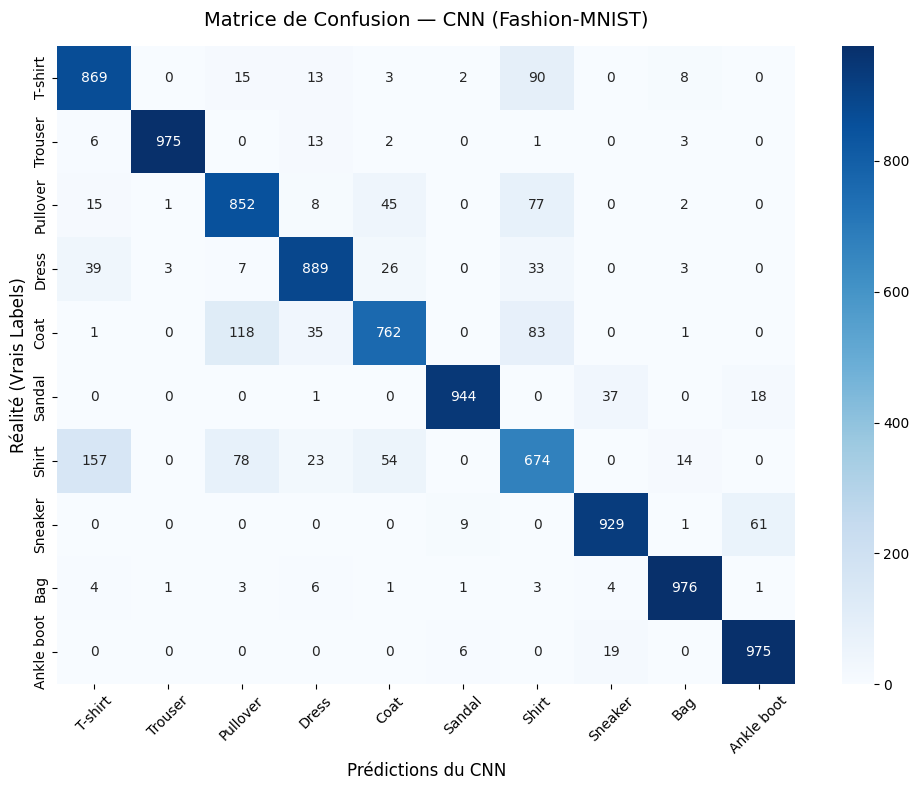

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. PHASE D'ÉVALUATION SUR LE JEU DE TEST
model_cnn.eval() # Gel des poids
all_preds = []
all_labels = []

# Désactivation du gradient (gain de temps et de mémoire)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Prédictions brutes (Logits)
        outputs = model_cnn(images)

        # On garde la classe ayant le score le plus élevé (argmax)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. CALCUL ET AFFICHAGE DES MÉTRIQUES
accuracy = accuracy_score(all_labels, all_preds)
print(f"======================================================")
print(f"Accuracy globale du CNN (LeNet-5) : {accuracy*100:.2f}%")
print(f"======================================================")

# 3. TRACÉ DE LA MATRICE DE CONFUSION
classes_noms = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
# On utilise une échelle de couleur "Blues" très pro pour les rapports
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_noms, yticklabels=classes_noms)
plt.title('Matrice de Confusion — CNN (Fashion-MNIST)', fontsize=14, pad=15)
plt.ylabel('Réalité (Vrais Labels)', fontsize=12)
plt.xlabel('Prédictions du CNN', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La matrice de confusion obtenue sur l'ensemble de test (10 000 images) confirme la robustesse de l'architecture CNN implémentée. La diagonale principale, très sombre, concentre la vaste majorité des prédictions, démontrant une excellente capacité de généralisation.Une analyse fine des erreurs (les valeurs hors diagonale) révèle le comportement inductif du réseau, qui se heurte à des ambiguïtés morphologiques logiques :Les forces du modèle (Formes distinctes) : Le réseau excelle sur les classes possédant une géométrie unique. Par exemple, les sacs (Bag : 976/1000 vrais positifs), les pantalons (Trouser : 975/1000) et les bottines (Ankle boot : 975/1000) sont reconnus avec une précision redoutable. Leurs contours globaux ne partagent quasiment aucun trait avec les autres classes.Le cluster des "Hauts" (Confusions sémantiques) : La majorité des erreurs du modèle se concentre sur les vêtements du haut du corps. La classe la moins bien prédite est la Chemise (Shirt, avec seulement 674 bonnes prédictions). Le réseau la confond massivement avec les T-shirts (157 erreurs), les pulls (Pullover, 78 erreurs) et les manteaux (Coat, 54 erreurs). À une résolution de $28 \times 28$ pixels, la différence entre les manches longues d'une chemise, d'un pull ou d'un manteau est minime. Le CNN capture les contours, mais manque de résolution pour distinguer les détails fins comme les boutons ou le type de col.Le cluster des "Chaussures" : On observe une légère confusion (61 erreurs) où des baskets (Sneaker) sont classifiées comme des bottines (Ankle boot), et inversement. Là encore, la forme de la semelle et le contour de la cheville se chevauchent fortement dans l'espace latent du modèle.Conclusion de l'expérience : Les erreurs du CNN ne sont pas aléatoires ; elles sont visuellement justifiées. Cela prouve que les couches de convolution ont bien appris à extraire des cartes de caractéristiques basées sur la géométrie des objets, remplissant parfaitement leur rôle théorique.